# [Машина (метод) опорных векторов](https://ru.wikipedia.org/wiki/%D0%9C%D0%B5%D1%82%D0%BE%D0%B4_%D0%BE%D0%BF%D0%BE%D1%80%D0%BD%D1%8B%D1%85_%D0%B2%D0%B5%D0%BA%D1%82%D0%BE%D1%80%D0%BE%D0%B2)

Метод был [изобретен в СССР.](https://ru.wikipedia.org/wiki/%D0%9C%D0%B5%D1%82%D0%BE%D0%B4_%D0%BE%D0%BF%D0%BE%D1%80%D0%BD%D1%8B%D1%85_%D0%B2%D0%B5%D0%BA%D1%82%D0%BE%D1%80%D0%BE%D0%B2#%D0%AF%D0%B4%D1%80%D0%B0)

In [ ]:
import numpy as np
import pandas as pd
from typing import Dict, Tuple
from scipy import stats
from IPython.display import Image
from sklearn.datasets import load_iris
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, balanced_accuracy_score
from sklearn.metrics import precision_score, recall_score, f1_score, classification_report
from sklearn.metrics import confusion_matrix
from sklearn.metrics import mean_absolute_error, mean_squared_error, mean_squared_log_error, median_absolute_error, r2_score 
from sklearn.metrics import roc_curve, roc_auc_score
from sklearn.preprocessing import MinMaxScaler
from sklearn.datasets import make_blobs, make_circles
from sklearn.model_selection import cross_val_score, cross_validate
from sklearn.svm import SVC, NuSVC, LinearSVC, OneClassSVM, SVR, NuSVR, LinearSVR
import seaborn as sns
import matplotlib.pyplot as plt
%matplotlib inline 
sns.set(style="ticks")

## Основная идея метода

In [1]:
Image('img/svm_planes.png', width='30%')

NameError: name 'Image' is not defined

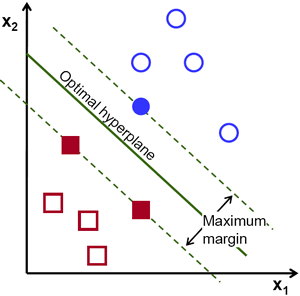

In [ ]:
Image('img/svm_opt_plane.png', width='30%')

**Основная идея метода** (из Википедии) — перевод исходных векторов в пространство более высокой размерности и поиск разделяющей гиперплоскости с максимальным зазором в этом пространстве. Две параллельных гиперплоскости строятся по обеим сторонам гиперплоскости, разделяющей классы. Разделяющей гиперплоскостью будет гиперплоскость, максимизирующая расстояние до двух параллельных гиперплоскостей. Алгоритм работает в предположении, что чем больше разница или расстояние между этими параллельными гиперплоскостями, тем меньше будет средняя ошибка классификатора. 

В качестве иллюстраций мы будем использовать [примеры кода](https://jakevdp.github.io/PythonDataScienceHandbook/05.07-support-vector-machines.html) из книги Дж. Вандер Плас "Python для сложных задач. Наука о данных и машинное обучение".

### Список используемых терминов
- **Вектор** - точка в многомерном пространстве. Соответствует одному объекту обучающей или тестовой выборки. В рассматриваемом примере это двухмерное пространство $(x_1, x_2)$
- **Опорный вектор** - такая точка, которая участвует в построении оптимальной гиперплоскости.
- **[Гиперплоскость](https://ru.wikipedia.org/wiki/%D0%93%D0%B8%D0%BF%D0%B5%D1%80%D0%BF%D0%BB%D0%BE%D1%81%D0%BA%D0%BE%D1%81%D1%82%D1%8C)** - подпространство с размерностью, на единицу меньшей, чем объемлющее пространство. Для двухмерного пространства (плоскости) частным случаем гиперплоскости является прямая, для трехмерного пространства гиперплоскостью является плоскость.
- **Разделяющая гиперплоскость** - гиперплоскость, которая каким-то образом разделяет вектора (точки в многомерном пространстве), принадлежащие различным классам. Возможно, разделяет с ошибками.
- **Оптимальная (разделяющая) гиперплоскость** - такая разделяющая гиперплоскость, которая обеспечивает максимальный зазор (margin) между векторами (точками) различных классов.

Примеры гиперплоскостей для двухмерного и трехмерного пространства


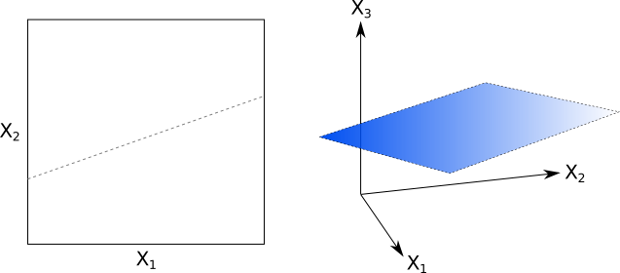

In [ ]:
print('Примеры гиперплоскостей для двухмерного и трехмерного пространства')
Image('img/hyperplanes.png', width='50%')

- **На этапе обучения (fit)** по точкам (векторам) обучающей выборки строится уравнение оптимальной разделяющей гиперплоскости. Это сложная задача, которая решается с применением методов оптимизации.
- **На этапе предсказания (predict)** точка тестовой выборки подставляется в полученное уравнение и определяется класс, к которому принадлежит точка.

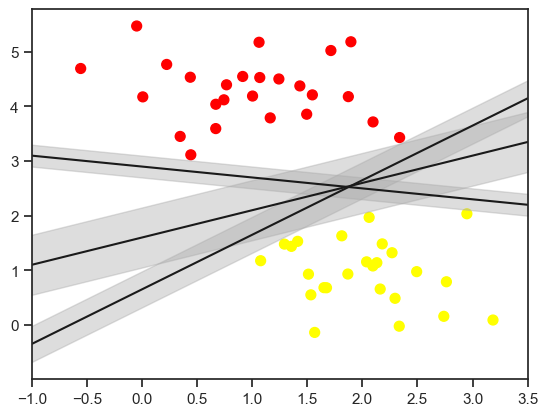

In [ ]:
# Пример кода из книги Дж. Вандер Пласа
X, y = make_blobs(n_samples=50, centers=2,
                  random_state=0, cluster_std=0.60)
xfit = np.linspace(-1, 3.5)
plt.scatter(X[:, 0], X[:, 1], c=y, s=50, cmap='autumn')

for m, b, d in [(1, 0.65, 0.33), (0.5, 1.6, 0.55), (-0.2, 2.9, 0.2)]:
    yfit = m * xfit + b
    plt.plot(xfit, yfit, '-k')
    plt.fill_between(xfit, yfit - d, yfit + d, edgecolor='none',
                     color='#AAAAAA', alpha=0.4)

plt.xlim(-1, 3.5);

## Задача классификации

### Классификатор

Рассмотрим уравнение гиперплоскости для двухмерного случая:

$$ y = k \cdot x + b $$

Произведем замены:

$$ x \rightarrow x_1 $$
$$ y \rightarrow x_2 $$
$$ b \rightarrow \frac{w_0}{w_2} $$
$$ k \rightarrow -\frac{w_1}{w_2} $$

Тогда:

$$ x_2 = -\frac{w_1}{w_2} \cdot x_1 + \frac{w_0}{w_2} $$

Домножим уравнение на $w_2$ и перенесем все в левую часть:

$$ w_2 \cdot x_2 + w_1 \cdot x_1 - w_0 = 0 $$

Чтобы обобщить уравнение на многомерный случай необходимо представить $x$ и $w$ в виде многомерных векторов. Тогда:

$$ <w,x> - w_0 = 0, $$

где $<w,x>$ - скалярное произведение векторов $w$ и $x$.

При этом вектор $w$ будет являться перпендикуляром к разделяющей гиперплоскости.

Модуль расстояния от гиперплоскости до начала координат равен $\frac{w_0}{||w||}$.

Каждому вектору (объекту обучающей выборки) $x_i$ можно сопоставить результирующий класс бинарного классификатора $y_i$, который можно трактовать как знак:

$$ (<w,x_i> - w_0) \rightarrow (y_i = \{-1,+1\}) $$

или

$$ y_i(<w,x_i> - w_0) = sign(<w,x_i> - w_0) = \{-1,+1\} $$

где $ sign(...) = \{-1,+1\} $ - функция определения знака, которая задает порог.

Тогда мы строим линейный пороговый классификатор: 

$$ CLASS(x_i) = sign(<w,x_i> - w_0), $$



### Нормировка классификатора и ширина разделяющей полосы

Алгоритм работы классификатора $CLASS(x_i)$ не изменится, если его параметры $w$ и $w_0$ одновременно умножить на константу. После умножения получим новые значения $w'$ и $w_0'$.

Константу удобно выбрать таким образом, чтобы выполнялось условие:

$$ <w',x_i> - w_0' = y_i = \{-1,+1\} $$

Далее заменим $w' \rightarrow w$ и $w_0' \rightarrow w_0$ чтобы вернуться к исходным обозначениям.

Вспомним, что оптимальная гиперплоскость проходит посередине между двух ограничивающих гиперплоскостей, которые создают зазор:

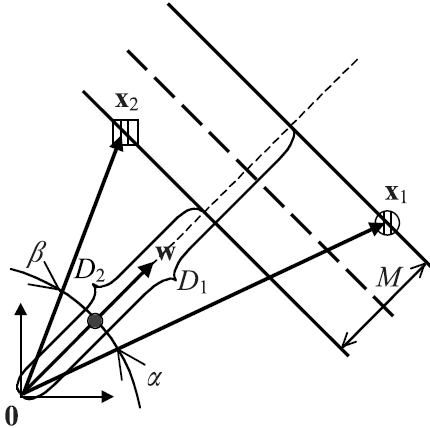

In [ ]:
Image('img/svm_opt_plane_angle.png', width='30%')

Тогда уравнения ограничивающих гиперплоскостей:

$$ <w,x_i> - w_0 = 1 $$

и

$$ <w,x_i> - w_0 = -1 $$

Полоса, разделяющая классы определяется условием:

$$ -1 <  \langle w,x_i \rangle - w_0  < 1 $$

Пусть вектор $x_2$ относится к отрицательному классу $y(x_2)=-1$, 
а вектор $x_1$ относится к положительному классу $y(x_1)=1$.

Тогда ширина разделяющей полосы $Margin$ является проекцией разности векторов на перпендикуляр к разделяющей гиперплоскости:

$$Margin = Projection_w (x_1 - x_2) $$

Тогда:

$$ D_1 = ||x_1|| \cdot cos(\alpha) $$
$$ D_2 = ||x_2|| \cdot cos(\beta) $$
$$ Margin = D_1 - D2 $$

Но по свойствам скалярного произведения:

$$ cos(\alpha) = \frac{\langle w,x_1 \rangle}{||x_1|| \cdot ||w||} $$

$$ cos(\beta) = \frac{\langle w,x_2 \rangle}{||x_2|| \cdot ||w||} $$

Тогда: 

$$ Margin = D_1 - D_2 = \frac{\langle w,x_1 \rangle - \langle w,x_2 \rangle}{||w||} $$

Вектора $x_1$ и $x_2$ являются опорными, а значит лежат на ограничивающих гиперплоскостях. Следовательно для вектора $x_1$:

$$ \langle w,x_1 \rangle - w_0 = 1$$
$$ \langle w,x_1 \rangle = w_0 + 1$$

Аналогично для вектора $x_2$:

$$ \langle w,x_2 \rangle - w_0 = -1$$
$$ \langle w,x_2 \rangle = w_0 - 1$$

Тогда: 

$$ Margin = D_1 - D_2 = \frac{\langle w,x_1 \rangle - \langle w,x_2 \rangle}{||w||} = \frac{(w_0+1)-(w_0-1)}{||w||} = \frac{2}{||w||}$$


Чтобы ширина разделяющей полосы была максимальной, нужно минимизировать $||w||$.

Далее можно рассмотреть два случая:

1. **Случай линейной разделимости.** Идеальное решение задачи. В этом случае ни одна из точек не попадает внутрь разделяющей полосы.
1. **Случай линейной неразделимости.** Более частый случай на практике, когда часть точек все-таки попадает внутрь разделяющей полосы. Но необходимо сделать так, чтобы количество таких точек было минимально.

### Случай линейной разделимости (hard-margin)

$$
\left \{
\begin{array}{>{\displaystyle\tallstrut}l@{}}
||w||^2 = \langle w,w \rangle \rightarrow min \\
y_i \Big( \langle w,x_i \rangle - w_0 \Big) \geqslant 1, i=1..k
\end{array}
\right.
$$

Первое уравнение говорит о том, что мы решаем задачу минимизации $w$.

Второе уравнение говорит о том, что все точки (вектора) должны лежать за пределами разделяющей полосы. $w$.

По [теореме Каруша—Куна—Таккера](https://ru.wikipedia.org/wiki/%D0%A3%D1%81%D0%BB%D0%BE%D0%B2%D0%B8%D1%8F_%D0%9A%D0%B0%D1%80%D1%83%D1%88%D0%B0_%E2%80%94_%D0%9A%D1%83%D0%BD%D0%B0_%E2%80%94_%D0%A2%D0%B0%D0%BA%D0%BA%D0%B5%D1%80%D0%B0) эта задача эквивалентна двойственной задаче поиска седловой точки функции Лагранжа:

$$
\left \{
\begin{array}{>{\displaystyle\tallstrut}l@{}}
L(w, w_0, \lambda) = \frac{1}{2} \langle w,w \rangle - \sum\limits_{i=1}^k \lambda_i ( y_i (\langle w,x_i \rangle - w_0) -1) \rightarrow min_{w, w_0} max_{\lambda} \\
\lambda_i \geqslant 0, i=1..k \\
\lambda_i = 0, либо (\langle w,x_i \rangle - w_0 = y_i), i=1..k 
\end{array}
\right.
$$

где $\lambda_i$ - [множители Лагранжа.](https://ru.wikipedia.org/wiki/%D0%9C%D0%B5%D1%82%D0%BE%D0%B4_%D0%BC%D0%BD%D0%BE%D0%B6%D0%B8%D1%82%D0%B5%D0%BB%D0%B5%D0%B9_%D0%9B%D0%B0%D0%B3%D1%80%D0%B0%D0%BD%D0%B6%D0%B0)

Третье уравнение называется условием дополняющей нежесткости.

Необходимым условием седловой точки является равенство нулю производных Лагранжиана:

$$ \frac{\partial L}{\partial w} = w - \sum\limits_{i=1}^k \lambda_i y_i x_i = 0 $$

Следовательно:

$$ w = \sum\limits_{i=1}^k \lambda_i y_i x_i $$

И

$$ \frac{\partial L}{\partial w_0} = - \sum\limits_{i=1}^k \lambda_i y_i = 0 $$

Следовательно:

$$ \sum\limits_{i=1}^k \lambda_i y_i = 0 $$

Искомый вектор весов $w$ является линейной комбинацией векторов обучающей выборки, причем только тех, для которых $\lambda_i \ne 0$. Согласно
условию дополняющей нежесткости на этих векторах $x_i$ ограничения-неравенства обращаются в равенства: $\langle w,x_i \rangle - w_0 = y_i$, следовательно, эти вектора находятся на границе разделяющей полосы. Все остальные векторы отстоят дальше от границы и не участвуют в сумме. Алгоритм не изменился бы, если бы этих векторов вообще не было в обучающей выборке.

Если $\lambda_i > 0$ и $\langle w,x_i \rangle - w_0 = y_i$, то объект обучающей выборки $x_i$ называется опорным вектором.

Подставляя условия равенства производных нулю обратно в Лагранжиан, получаем эквивалентную задачу квадратичного программирования, содержащую только двойственные переменные:

$$
\left \{
\begin{array}{>{\displaystyle\tallstrut}l@{}}
-L(\lambda) = - \sum\limits_{i=1}^k \lambda_i + \frac{1}{2} \sum\limits_{i=1}^k \sum\limits_{j=1}^k \lambda_i \lambda_j y_i y_j \langle x_i,x_j \rangle \rightarrow min_{\lambda} \\
\lambda_i \geqslant 0, i=1..k \\
\sum\limits_{i=1}^k \lambda_i y_i = 0
\end{array}
\right.
$$

Известно, что данная задача имеет единственное решение и тогда $w$ и $w_0$ можно найти на основании следующих формул:

$$ w = \sum\limits_{i=1}^k \lambda_i y_i x_i $$

$$ w_0 = \langle w,x_i \rangle - y_i $$

Тогда алгоритм классификации может быть записан в следующем виде:

$$ CLASS(x_i) = sign \Big( \sum\limits_{i=1}^k \lambda_i y_i \langle x_i,x \rangle - w_0 \Big) $$

При этом суммирование идёт не по всей выборке, а только по опорным векторам, для которых $\lambda _{i} \neq 0$.

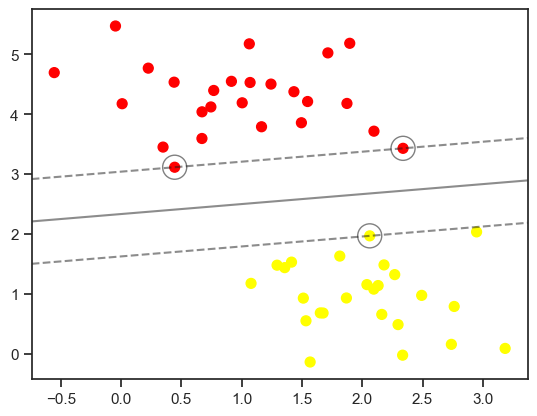

In [ ]:
# Пример кода из книги Дж. Вандер Пласа
def plot_svc_decision_function(model, ax=None, plot_support=True):
    """Plot the decision function for a 2D SVC"""
    if ax is None:
        ax = plt.gca()
    xlim = ax.get_xlim()
    ylim = ax.get_ylim()
    
    # create grid to evaluate model
    x = np.linspace(xlim[0], xlim[1], 30)
    y = np.linspace(ylim[0], ylim[1], 30)
    Y, X = np.meshgrid(y, x)
    xy = np.vstack([X.ravel(), Y.ravel()]).T
    P = model.decision_function(xy).reshape(X.shape)
    
    # plot decision boundary and margins
    ax.contour(X, Y, P, colors='k',
               levels=[-1, 0, 1], alpha=0.5,
               linestyles=['--', '-', '--'])
    
    # plot support vectors
    if plot_support:
        ax.scatter(model.support_vectors_[:, 0],
                   model.support_vectors_[:, 1],
                   s=300, linewidth=1, color='none', edgecolor='grey');
    ax.set_xlim(xlim)
    ax.set_ylim(ylim)
    
model = SVC(kernel='linear', C=1E10)
model.fit(X, y) 

plt.scatter(X[:, 0], X[:, 1], c=y, s=50, cmap='autumn')
plot_svc_decision_function(model)   

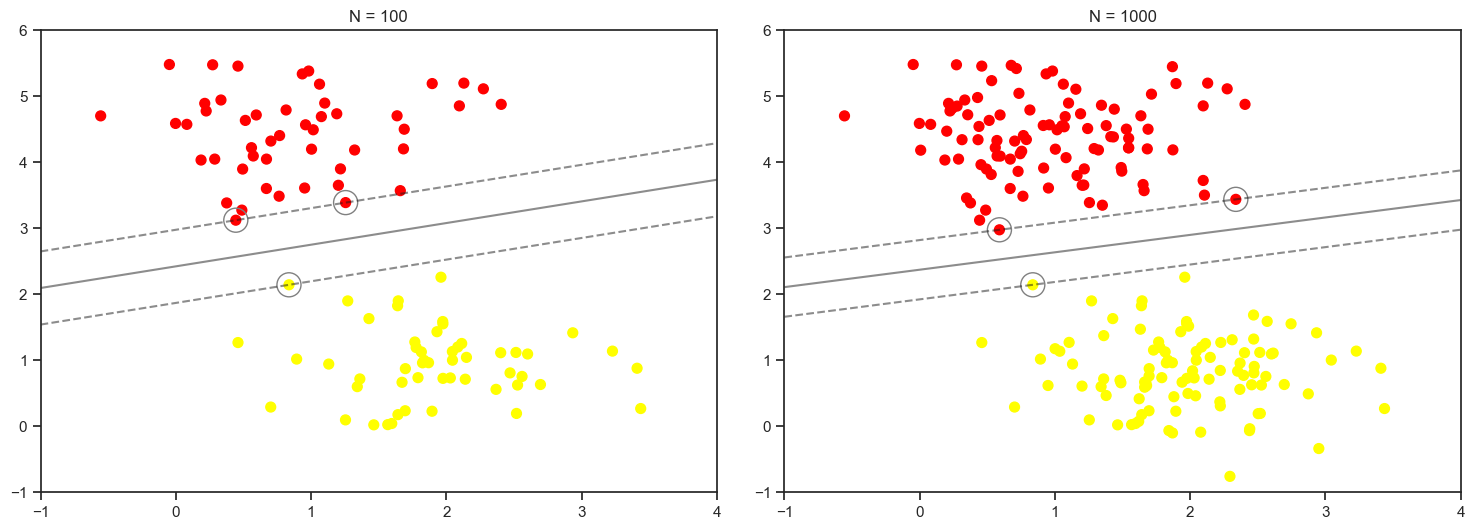

In [ ]:
# Пример кода из книги Дж. Вандер Пласа
def plot_svm(N=10, ax=None):
    X, y = make_blobs(n_samples=200, centers=2,
                      random_state=0, cluster_std=0.60)
    X = X[:N]
    y = y[:N]
    model = SVC(kernel='linear', C=1E10)
    model.fit(X, y)
    
    ax = ax or plt.gca()
    ax.scatter(X[:, 0], X[:, 1], c=y, s=50, cmap='autumn')
    ax.set_xlim(-1, 4)
    ax.set_ylim(-1, 6)
    plot_svc_decision_function(model, ax)
    
fig, ax = plt.subplots(1, 2, figsize=(16, 6))
fig.subplots_adjust(left=0.0625, right=0.95, wspace=0.1)
for axi, N in zip(ax, [100, 1000]):
    plot_svm(N, axi)
    axi.set_title('N = {0}'.format(N))    

### Случай линейной неразделимости (soft-margin)

Будем допускать попадание части опорных векторов внутрь разделительной полосы.

В данном случае необходимо смягчить условия линейной разделимости. Набор дополнительных переменных $\xi_i \geqslant 0$ характеризует величину ошибки на объектах $x_i$.

Тогда задача оптимизации записывается следующим образом:

$$
\left \{
\begin{array}{>{\displaystyle\tallstrut}l@{}}
\frac{1}{2}\langle w,w \rangle + C \sum\limits_{i=1}^k \xi_i \rightarrow min_{w,w_0, \xi} \\
y_i \Big( \langle w,x_i \rangle - w_0 \Big) \geqslant 1 - \xi_i, i=1..k \\
\xi_i \geqslant 0, i=1..k
\end{array}
\right.
$$

Проведя рассуждения, аналогичные случаю линейной разделимости получаем эквивалентную задачу квадратичного программирования, содержащую только двойственные переменные:

$$
\left \{
\begin{array}{>{\displaystyle\tallstrut}l@{}}
-L(\lambda) = - \sum\limits_{i=1}^k \lambda_i + \frac{1}{2} \sum\limits_{i=1}^k \sum\limits_{j=1}^k \lambda_i \lambda_j y_i y_j \langle x_i,x_j \rangle \rightarrow min_{\lambda} \\
0 \leqslant \lambda_i \leqslant C, i=1..k \\
\sum\limits_{i=1}^k \lambda_i y_i = 0
\end{array}
\right.
$$


В данном случае алгоритм классификации также может быть записан в виде:

$$ CLASS(x_i) = sign \Big( \sum\limits_{i=1}^k \lambda_i y_i \langle x_i,x \rangle - w_0 \Big) $$

Но теперь ненулевыми $\lambda_i$ обладают не только опорные объекты, но и объекты-нарушители. Это можно считать недостатком метода, потому что  нарушителями часто оказываются шумовые выбросы, и построенное на них решающее правило опирается на шумовые данные.

Константа $C$ обычно выбирается с помощью кросс-валидации.

Очень важно то, что в решение входят не сами признаки $x_i$, а их скалярные произведения $\langle x_i,x \rangle$. Это позволяет ускорить работу метода в том случае, когда можно представить признаки в виде скалярных произведений. На этом же принципе основан "ядерный трюк".

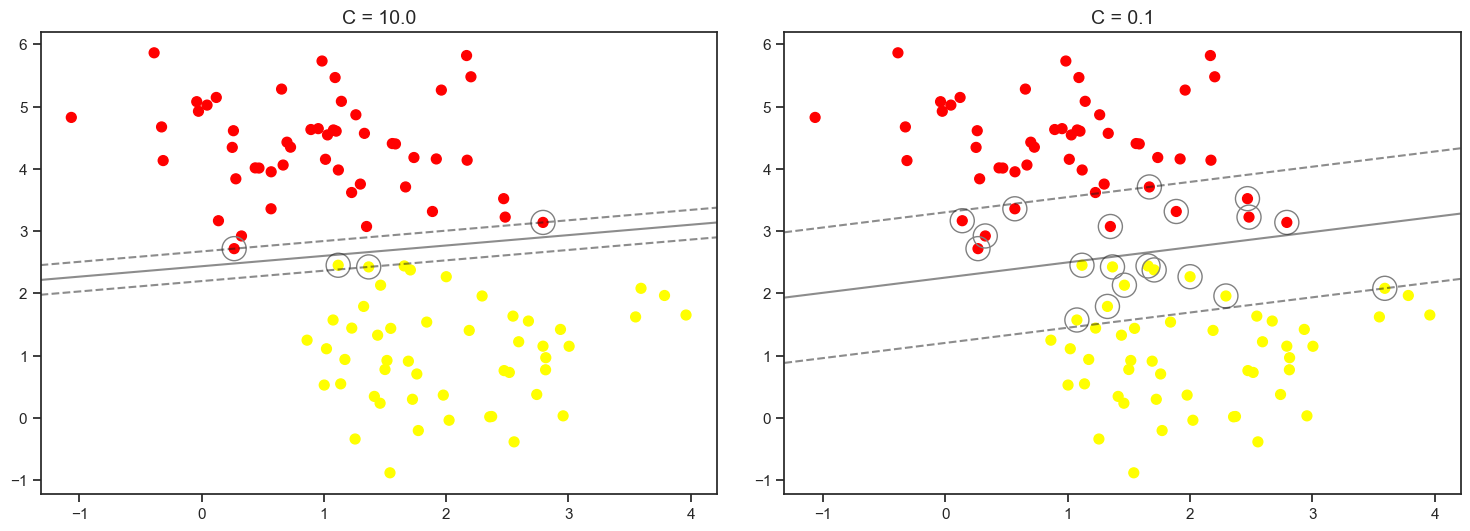

In [ ]:
# Пример кода из книги Дж. Вандер Пласа
X, y = make_blobs(n_samples=100, centers=2,
                  random_state=0, cluster_std=0.8)

fig, ax = plt.subplots(1, 2, figsize=(16, 6))
fig.subplots_adjust(left=0.0625, right=0.95, wspace=0.1)

for axi, C in zip(ax, [10.0, 0.1]):
    model = SVC(kernel='linear', C=C).fit(X, y)
    axi.scatter(X[:, 0], X[:, 1], c=y, s=50, cmap='autumn')
    plot_svc_decision_function(model, axi)
    axi.scatter(model.support_vectors_[:, 0],
                model.support_vectors_[:, 1],
                s=300, lw=1, facecolors='none');
    axi.set_title('C = {0:.1f}'.format(C), size=14)

### Использование SVM для нелинейных разделяющих поверхностей или "ядерный трюк" (kernel trick)

Основная идея состоит в том, что в скалярное произведение можно подставить не сам признак, а некоторую функцию от признака. Функция может переводить признак в пространство большей размерности и SVM начинает вычислять нелинейную разделяющую поверхность.

Пусть есть некоторое преобразование $ \phi: X \rightarrow H $, где $H$ - пространство, на котором определено скалярное произведение.

Тогда функция $K : X \times X \rightarrow R $ называется ядром, если она представима в виде $ K(x,x') = \langle \phi(x),\phi(x') \rangle $.

По [теореме Мерсера](http://www.machinelearning.ru/wiki/index.php?title=%D0%A2%D0%B5%D0%BE%D1%80%D0%B5%D0%BC%D0%B0_%D0%9C%D0%B5%D1%80%D1%81%D0%B5%D1%80%D0%B0) функция является ядром тогда и только тогда, когда она:

1) симметрична, то есть: 

$$ K(x,x') = K(x',x) $$


2) неотрицательно определена, то есть:

$$ \int_{X} \int_{X} K(x,x')g(x)g(x')dxdx' \geqslant 0 $$

для любой функции $g : X \rightarrow R$.

**Существует очень немного функций, которые бы удовлетворяли теореме Мерсера. Наиболее известными из них являются:**

1) Линейная (ядро не используется):

$$ K(x,x') = \langle x,x' \rangle $$

2) Полиномиальная:

$$ K(x,x') = \Big(\gamma \langle x,x' \rangle + coef0\Big)^{degree} $$

3) Радиальная базисная функция (rbf):

$$ K(x,x') = e^{-\gamma ||x-x'||^2}, \gamma > 0$$

4) Сигмоидальная:

$$ K(x,x') = tanh\Big(\gamma \langle x,x' \rangle + coef0\Big) $$

Данные ядра поддерживаются библиотекой [scikit-learn.](https://scikit-learn.org/stable/modules/svm.html#kernel-functions)

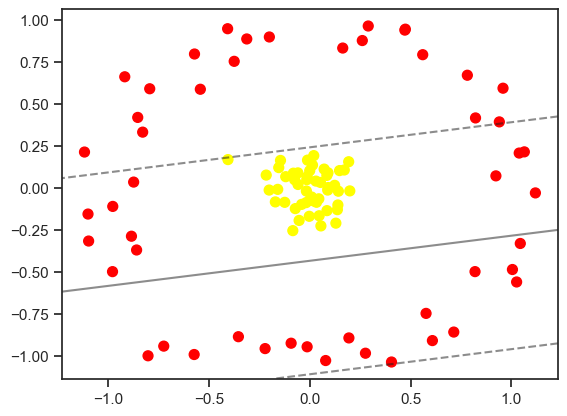

In [ ]:
# Пример кода из книги Дж. Вандер Пласа
X, y = make_circles(100, factor=.1, noise=.1)

clf = SVC(kernel='linear').fit(X, y)

plt.scatter(X[:, 0], X[:, 1], c=y, s=50, cmap='autumn')
plot_svc_decision_function(clf, plot_support=False);

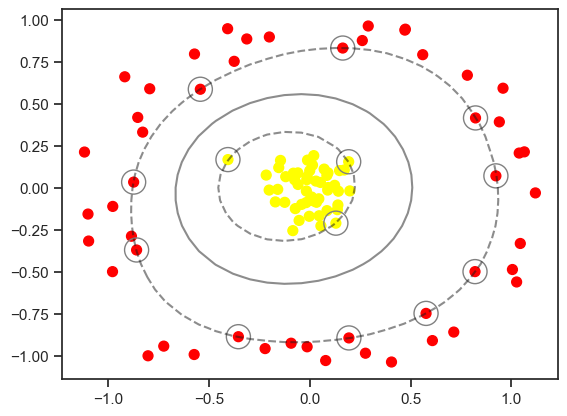

In [ ]:
# Пример кода из книги Дж. Вандер Пласа
clf = SVC(kernel='rbf', C=1E6)
clf.fit(X, y)

plt.scatter(X[:, 0], X[:, 1], c=y, s=50, cmap='autumn')
plot_svc_decision_function(clf)
plt.scatter(clf.support_vectors_[:, 0], clf.support_vectors_[:, 1],
            s=300, lw=1, facecolors='none');

In [ ]:
from IPython.display import YouTubeVideo
YouTubeVideo('3liCbRZPrZA', width=640, height=480)

## Особенности использования SVM для задач регрессии

Данный метод называется SVR - Support Vector machine Regression.

В этом случае $y_i$ рассматривается как действительное значение и вместо функции $sign( \langle w,x_i \rangle - w_0)$ также вычисляется действительная функция $\langle w,x_i \rangle - w_0$.

Для применения SVM к задаче регрессии используется следующая постановка:

$$
\left \{
\begin{array}{>{\displaystyle\tallstrut}l@{}}
||w||^2 = \langle w,w \rangle \rightarrow min \\
y_i - \langle w,x_i \rangle - w_0 \leqslant \epsilon \\
\langle w,x_i \rangle + w_0 - y_i \leqslant \epsilon 
\end{array}
\right.
$$

где $\epsilon$ - порог, все значения, попадающие в $\epsilon$-окрестность считаются верными.

## Преимущества метода
- Метод показывает очень хорошие практические результаты.
- Задача выпуклого квадратичного программирования имеет единственное  решение.
- С использованием "ядерного трюка" возможно построение нелинейных разделяющих поверхностей.

## Недостатки метода
- Метод чувствителен к обучающей выборке (в том числе к выбросам в данных), так как гиперплоскость строится на опорных векторах (граничных точках). Если в обучающую вылорку попали другие точки, то гиперплоскость может быть построена иначе. 
- Нет общего подхода к оптимизации ядер под конкретную задачу.
- Необходимо подбирать гиперпараметры, что является ресурсоемкой задачей.

## Реализация в [scikit-learn](https://scikit-learn.org/stable/modules/svm.html)

### Задача классификации
Для решения задачи классификации используются классы:
- [SVC](https://scikit-learn.org/stable/modules/generated/sklearn.svm.SVC.html) - основной классификатор на основе SVM. Поддерживает различные ядра.
- [NuSVC](https://scikit-learn.org/stable/modules/generated/sklearn.svm.NuSVC.html) - разновидность SVC с поддержкой параметра nu ($\nu \in (0,1]$), который определяет нижнюю границу доли опорных векторов.
- [LinearSVC](https://scikit-learn.org/stable/modules/generated/sklearn.svm.LinearSVC.html) - линейный классификатор на основе SVM. Не поддерживает ядра, работает быстрее других методов.

In [ ]:
# Используем датасет iris с двумя первыми признаками
iris = load_iris()
iris_X = iris.data[:, :2]
iris_y = iris.target

In [ ]:
def make_meshgrid(x, y, h=.02):
    """Create a mesh of points to plot in

    Parameters
    ----------
    x: data to base x-axis meshgrid on
    y: data to base y-axis meshgrid on
    h: stepsize for meshgrid, optional

    Returns
    -------
    xx, yy : ndarray
    """
    x_min, x_max = x.min() - 1, x.max() + 1
    y_min, y_max = y.min() - 1, y.max() + 1
    xx, yy = np.meshgrid(np.arange(x_min, x_max, h),
                         np.arange(y_min, y_max, h))
    return xx, yy

def plot_contours(ax, clf, xx, yy, **params):
    """Plot the decision boundaries for a classifier.

    Parameters
    ----------
    ax: matplotlib axes object
    clf: a classifier
    xx: meshgrid ndarray
    yy: meshgrid ndarray
    params: dictionary of params to pass to contourf, optional
    """
    Z = clf.predict(np.c_[xx.ravel(), yy.ravel()])
    Z = Z.reshape(xx.shape)
    #Можно проверить все ли метки классов предсказываются
    #print(np.unique(Z))
    out = ax.contourf(xx, yy, Z, **params)
    return out


def plot_cl(clf):
    title = clf.__repr__
    clf.fit(iris_X, iris_y)
    fig, ax = plt.subplots(figsize=(5,5))
    X0, X1 = iris_X[:, 0], iris_X[:, 1]
    xx, yy = make_meshgrid(X0, X1)
    plot_contours(ax, clf, xx, yy, cmap=plt.cm.coolwarm, alpha=0.8)
    ax.scatter(X0, X1, c=iris_y, cmap=plt.cm.coolwarm, s=20, edgecolors='k')
    ax.set_xlim(xx.min(), xx.max())
    ax.set_ylim(yy.min(), yy.max())
    ax.set_xlabel('Sepal length')
    ax.set_ylabel('Sepal width')
    ax.set_xticks(())
    ax.set_yticks(())
    ax.set_title(title)
    plt.show()

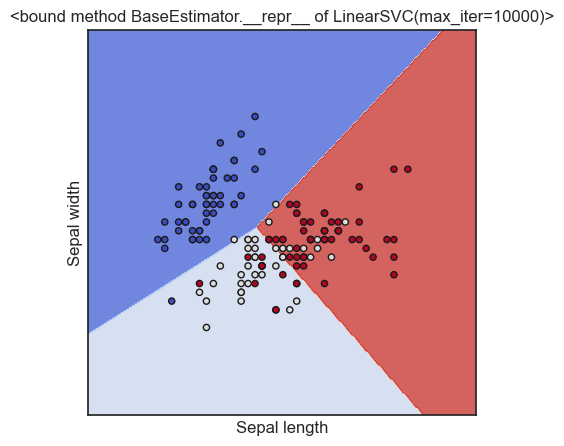

In [ ]:
plot_cl(LinearSVC(C=1.0, max_iter=10000))

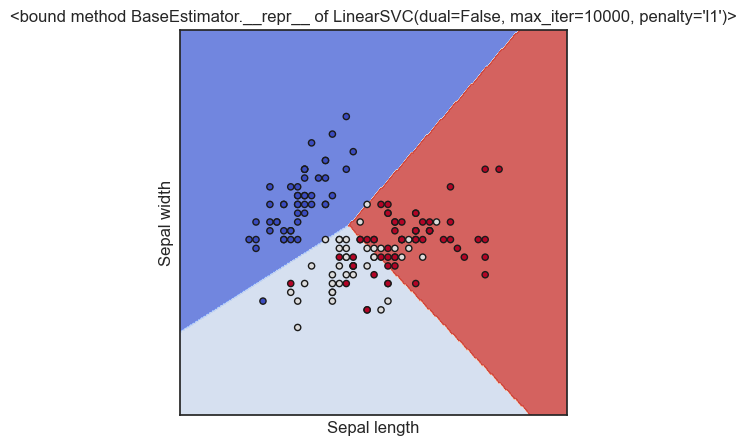

In [ ]:
plot_cl(LinearSVC(C=1.0, penalty='l1', dual=False, max_iter=10000))

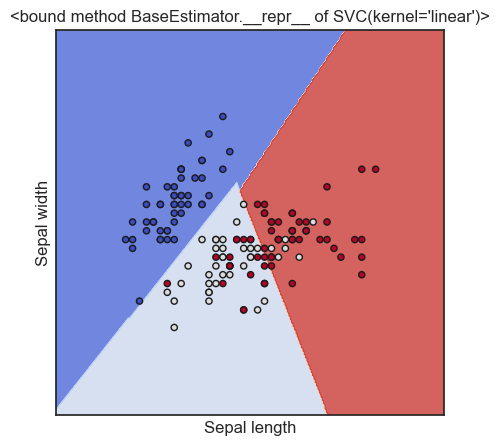

In [ ]:
plot_cl(SVC(kernel='linear', C=1.0))

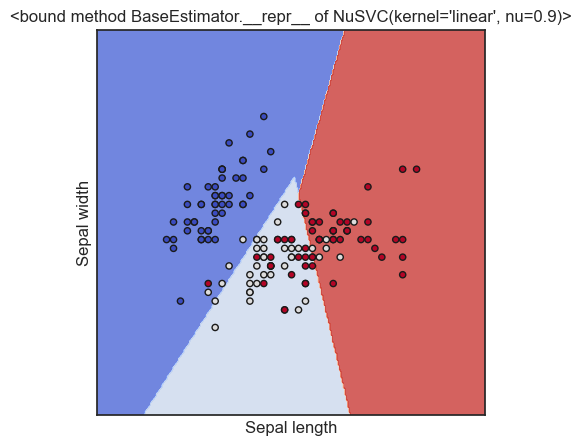

In [ ]:
plot_cl(NuSVC(kernel='linear', nu=0.9))

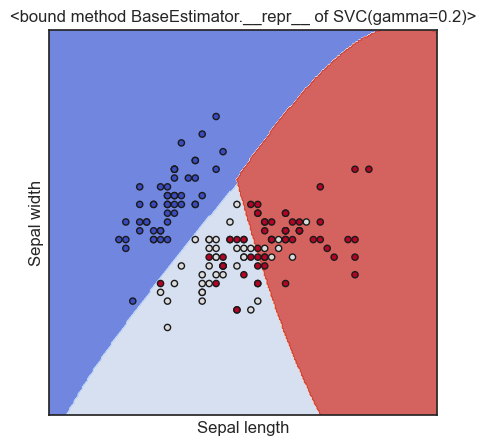

In [ ]:
plot_cl(SVC(kernel='rbf', gamma=0.2, C=1.0))

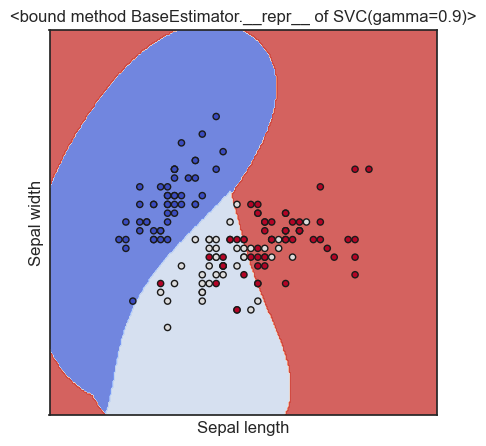

In [ ]:
plot_cl(SVC(kernel='rbf', gamma=0.9, C=1.0))

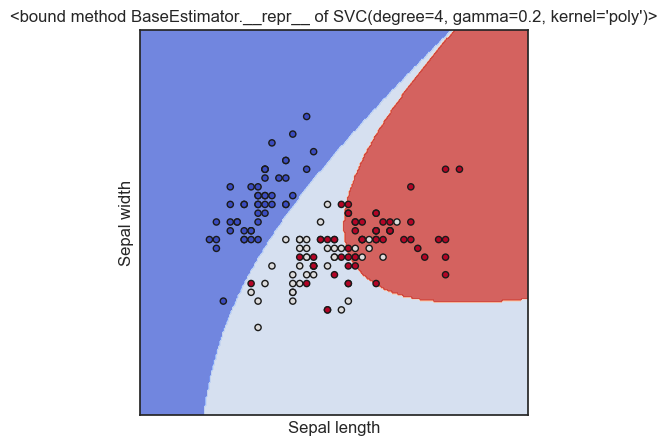

In [ ]:
plot_cl(SVC(kernel='poly', degree=4, gamma=0.2, C=1.0))

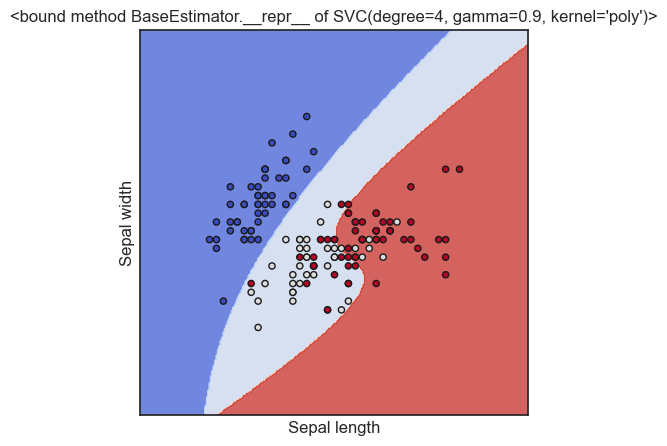

In [ ]:
plot_cl(SVC(kernel='poly', degree=4, gamma=0.9, C=1.0))

#### Как реализована многоклассовая классификация?

- Классы SVC и NuSVC используют стратегию "one-versus-one", то есть строят разделяющие поверхности отдельно для каждой пары классов. Далее разделяющие поверхности (по возможности) гладко соединяются друг с другом. Всего обучается  `n_classes * (n_classes - 1) / 2` моделей.
- Класс LinearSVC использует стратегию "one-versus-the-rest", то есть разделяющая поверхность строится между классом и всеми остальными классами. Далее разделяющие поверхности (по возможности) гладко соединяются друг с другом. Всего обучается  `n_classes` моделей.

### Задача регрессии
Для решения задачи регрессии используются классы:
- [SVR](https://scikit-learn.org/stable/modules/generated/sklearn.svm.SVR.html) - основной регрессор на основе SVM. Поддерживает различные ядра.
- [NuSVR](https://scikit-learn.org/stable/modules/generated/sklearn.svm.NuSVR.html) - разновидность SVR с поддержкой параметра nu ($\nu \in (0,1]$), который определяет нижнюю границу доли опорных векторов.
- [LinearSVR](https://scikit-learn.org/stable/modules/generated/sklearn.svm.LinearSVR.html) - линейный регрессор на основе SVM. Не поддерживает ядра, работает быстрее других методов.

In [ ]:
Housing = pd.read_csv('data/housing_train.csv', sep=",")
Housing_regr = Housing.drop(columns='ocean_proximity')
boston_x = Housing_regr['median_income'].values
boston_y = Housing_regr['median_house_value'].values

<Axes: >

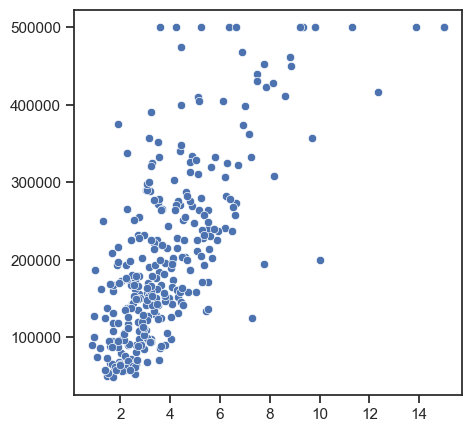

In [ ]:
fig, ax = plt.subplots(figsize=(5,5)) 
sns.scatterplot(ax=ax, x=boston_x, y=boston_y)

In [ ]:
def plot_regr(clf):
    title = clf.__repr__
    clf.fit(boston_x.reshape(-1, 1), boston_y)
    boston_y_pred = clf.predict(boston_x.reshape(-1, 1))
    fig, ax = plt.subplots(figsize=(5,5))
    ax.set_title(title)
    ax.plot(boston_x, boston_y, 'b.')
    ax.plot(boston_x, boston_y_pred, 'ro')
    plt.show()

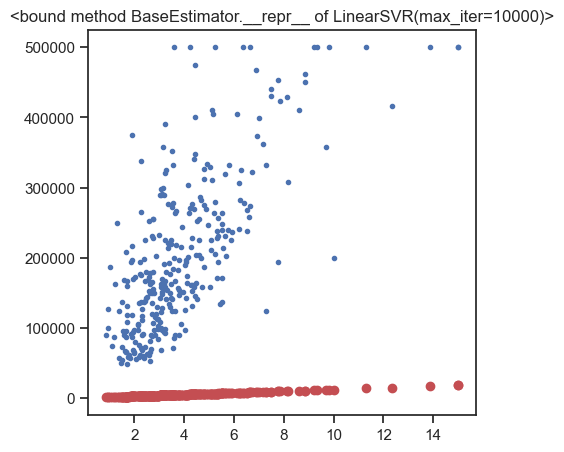

In [ ]:
plot_regr(LinearSVR(C=1.0, max_iter=10000))

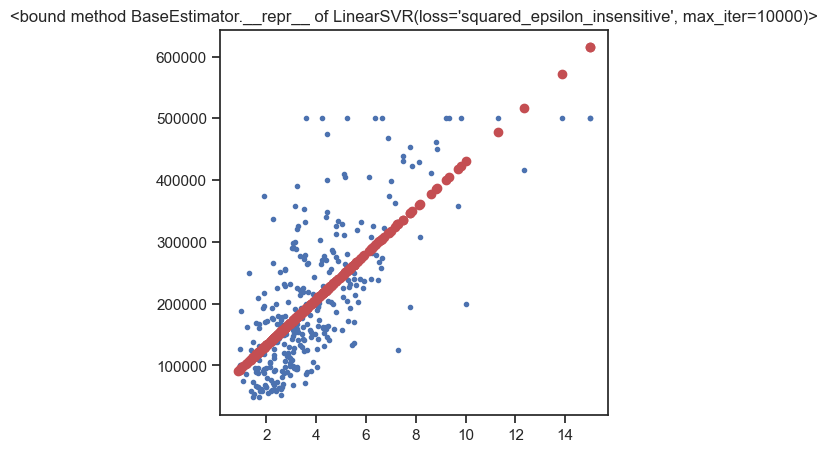

In [ ]:
plot_regr(LinearSVR(C=1.0, loss='squared_epsilon_insensitive', max_iter=10000))

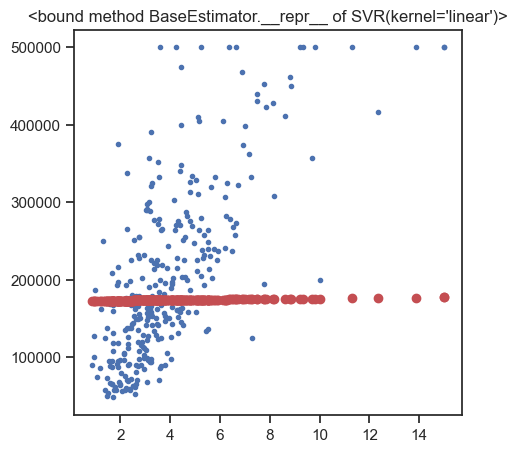

In [ ]:
plot_regr(SVR(kernel='linear', C=1.0))

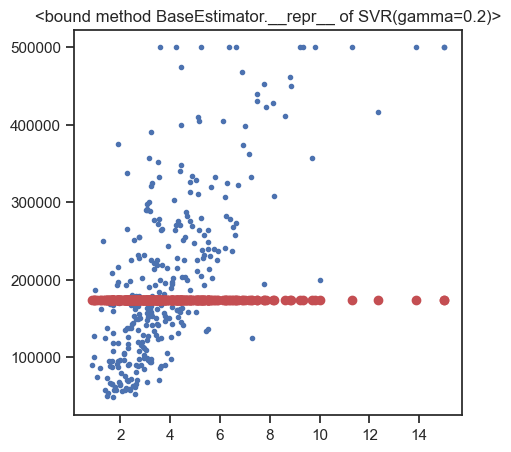

In [ ]:
plot_regr(SVR(kernel='rbf', gamma=0.2, C=1.0))

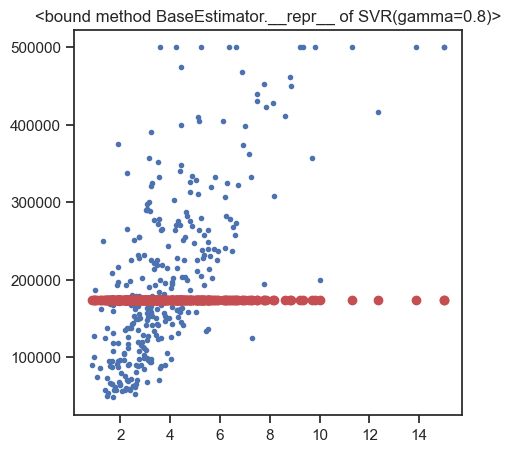

In [ ]:
plot_regr(SVR(kernel='rbf', gamma=0.8, C=1.0))

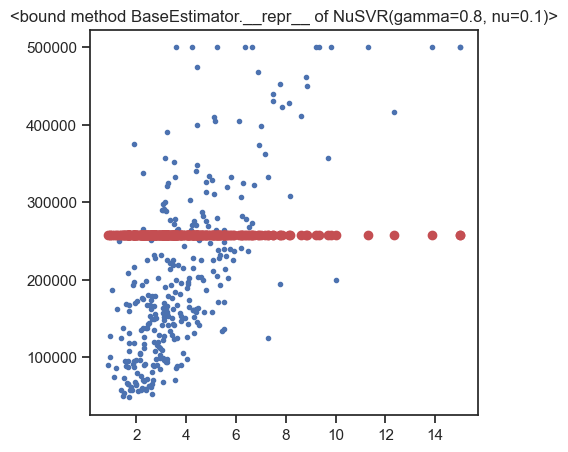

In [ ]:
plot_regr(NuSVR(kernel='rbf', gamma=0.8, nu=0.1, C=1.0))

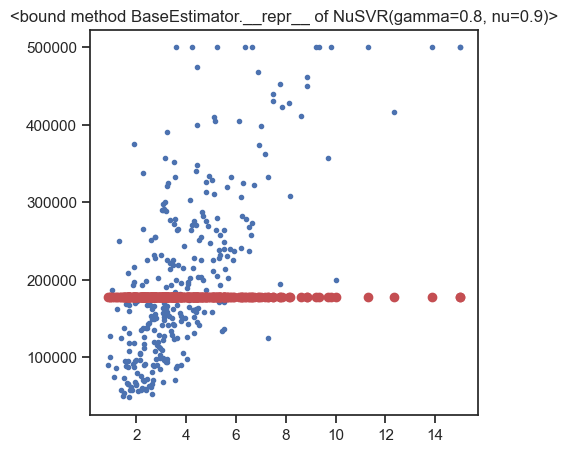

In [ ]:
plot_regr(NuSVR(kernel='rbf', gamma=0.8, nu=0.9, C=1.0))

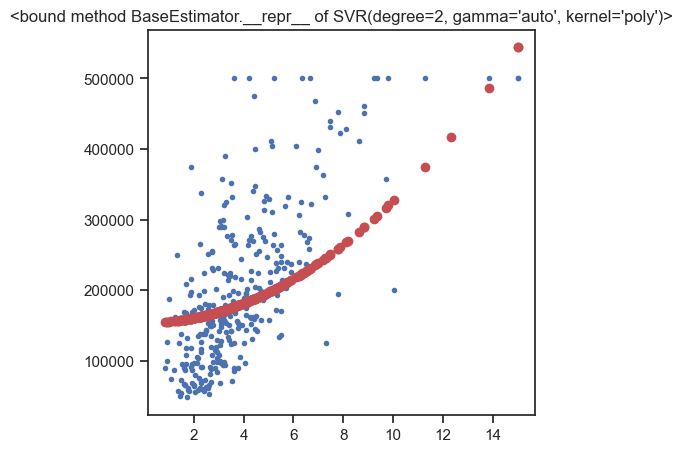

In [ ]:
plot_regr(SVR(kernel='poly', degree=2, gamma='auto', C=1.0))

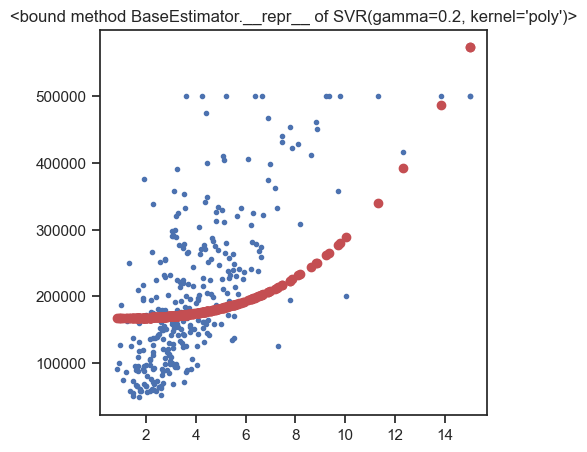

In [ ]:
plot_regr(SVR(kernel='poly', degree=3, gamma=0.2, C=1.0))

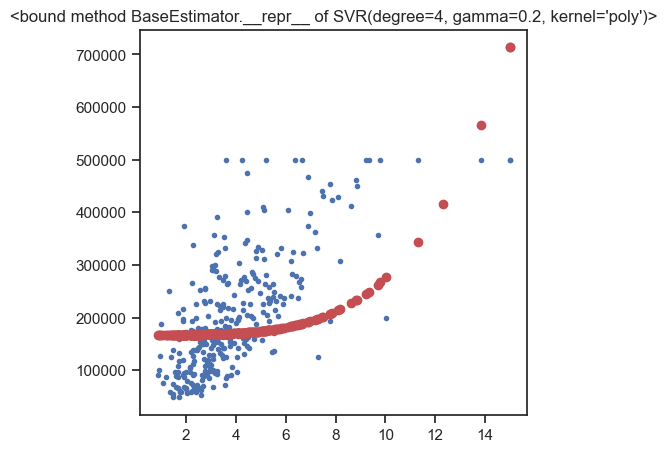

In [ ]:
plot_regr(SVR(kernel='poly', degree=4, gamma=0.2, C=1.0))

### Влияние масштабирования на работу алгоритма

In [ ]:
Housing_regr.head()

,longitude,latitude,housing_median_age,total_rooms,total_bedrooms,population,households,median_income,ocean_proximity_regr,median_house_value
0,-122.50,37.75,44.0,1819.0,537.870553,1137.0,354.0,3.4919,1,271800.0
1,-118.50,34.46,17.0,10267.0,537.870553,4956.0,1483.0,5.5061,0,239400.0
2,-122.39,37.60,34.0,707.0,537.870553,381.0,156.0,4.3750,1,340900.0
3,-117.96,34.03,35.0,2093.0,537.870553,1755.0,403.0,3.4115,0,150400.0
4,-121.13,38.87,48.0,1127.0,537.870553,530.0,186.0,3.0917,0,128100.0


In [ ]:
boston_x_columns = ['longitude', 'latitude', 'housing_median_age', 'total_rooms', 'total_bedrooms', 'population', 'households', 'median_income', 'median_house_value']

In [ ]:
# Диапазоны значений достаточно сильно различаются
Housing_regr[boston_x_columns].describe()

,longitude,latitude,housing_median_age,total_rooms,total_bedrooms,population,households,median_income,median_house_value
count,309.000000,309.000000,309.000000,309.000000,309.000000,309.000000,309.000000,309.000000,309.000000
mean,-119.339482,35.413430,29.158576,2591.035599,535.885455,1415.805825,495.941748,3.889942,203238.873786
std,2.000502,2.111197,12.292067,2001.371856,289.310725,967.496505,374.336326,2.173466,113118.884943
min,-124.060000,32.660000,5.000000,154.000000,22.000000,37.000000,16.000000,0.852700,48500.000000
25%,-121.350000,33.940000,18.000000,1373.000000,471.000000,779.000000,266.000000,2.475000,120200.000000
50%,-118.390000,34.170000,30.000000,2093.000000,537.870553,1183.000000,404.000000,3.333300,173400.000000
75%,-117.970000,37.510000,37.000000,3162.000000,537.870553,1795.000000,600.000000,4.712000,264600.000000
max,-114.590000,41.400000,52.000000,17579.000000,3479.000000,7604.000000,3589.000000,15.000100,500001.000000


#### Модель без масштабирования данных

In [ ]:
boston_X_train_1, boston_X_test_1, boston_y_train_1, boston_y_test_1 = train_test_split(
    Housing_regr[boston_x_columns], Housing_regr['median_house_value'], test_size=0.2, random_state=1)

boston_X_train_1.shape, boston_X_test_1.shape

((247, 9), (62, 9))

In [ ]:
svr_1 = SVR()
svr_1.fit(boston_X_train_1, boston_y_train_1)

SVR()

In [ ]:
boston_y_pred_1 = svr_1.predict(boston_X_test_1)

In [ ]:
mean_absolute_error(boston_y_test_1, boston_y_pred_1), mean_squared_error(boston_y_test_1, boston_y_pred_1)

(85633.00663835157, 13121995420.223047)

#### Модель с масштабированием данных

In [ ]:
# Масштабирование данных в диапазоне от 0 до 1
sc1 = MinMaxScaler()
sc1_data = sc1.fit_transform(Housing_regr[boston_x_columns])

In [ ]:
sc1_data[:2]

array([[0.16473073, 0.58237986, 0.82978723, 0.09555237, 0.14922492,
        0.14536805, 0.09459838, 0.18655018, 0.49457255],
       [0.58711721, 0.20594966, 0.25531915, 0.58037303, 0.14922492,
        0.65005947, 0.41057935, 0.32892263, 0.42281191]])

In [ ]:
boston_X_train_2, boston_X_test_2, boston_y_train_2, boston_y_test_2 = train_test_split(
    sc1_data, Housing_regr['median_house_value'], test_size=0.2, random_state=1)

boston_X_train_2.shape, boston_X_test_2.shape

((247, 9), (62, 9))

In [ ]:
svr_2 = SVR()
svr_2.fit(boston_X_train_2, boston_y_train_2)

SVR()

In [ ]:
boston_y_pred_2 = svr_2.predict(boston_X_test_2)

In [ ]:
mean_absolute_error(boston_y_test_2, boston_y_pred_2), mean_squared_error(boston_y_test_2, boston_y_pred_2)

(85655.3698378565, 13127733665.964113)

#### Эксперимент на основе кросс-валидации

In [ ]:
scoring = {'MAE': 'neg_mean_absolute_error', 
           'MSE': 'neg_mean_squared_error'}

In [ ]:
scores_1 = cross_validate(SVR(), 
                        Housing_regr[boston_x_columns], Housing_regr['median_house_value'], scoring=scoring, 
                        cv=3, return_train_score=True)
scores_1

{'fit_time': array([0.00400114, 0.        , 0.00927067]),
 'score_time': array([0.0009222 , 0.        , 0.00275898]),
 'test_MAE': array([-74910.96278086, -99940.51174703, -85959.32892131]),
 'train_MAE': array([-92913.96523472, -80397.45303105, -87389.85559294]),
 'test_MSE': array([-9.87675925e+09, -1.63976081e+10, -1.46856016e+10]),
 'train_MSE': array([-1.56449253e+10, -1.23256457e+10, -1.29986718e+10])}

In [ ]:
# Без масштабирования
-np.mean(scores_1['train_MAE']), -np.mean(scores_1['test_MAE']), \
-np.mean(scores_1['train_MSE']), -np.mean(scores_1['test_MSE'])

(86900.42461957033, 86936.93448306559, 13656414295.821444, 13653322985.675596)

In [ ]:
scores_2 = cross_validate(SVR(), 
                        sc1_data, Housing_regr['median_house_value'], scoring=scoring, 
                        cv=3, return_train_score=True)
scores_2

{'fit_time': array([0.        , 0.00103307, 0.        ]),
 'score_time': array([0.        , 0.        , 0.01149726]),
 'test_MAE': array([-74928.08832672, -99961.2545441 , -85977.33968255]),
 'train_MAE': array([-92932.90305376, -80414.00653413, -87409.6956529 ]),
 'test_MSE': array([-9.88089803e+09, -1.64035387e+10, -1.46905257e+10]),
 'train_MSE': array([-1.56506670e+10, -1.23297060e+10, -1.30039077e+10])}

In [ ]:
# С масштабированием
-np.mean(scores_2['train_MAE']), -np.mean(scores_2['test_MAE']), \
-np.mean(scores_2['train_MSE']), -np.mean(scores_2['test_MSE'])

(86918.86841359905, 86955.56085112486, 13661426906.742594, 13658320810.702148)

#### Выводы
Масштабирование признаков важно для работы машины опорных векторов. Если признаки представлены в различных масштабах, то это может отрицательно повлиять на сходимость градиентного спуска.

### Обнаружение аномалий с помощью класса [OneClassSVM](https://scikit-learn.org/stable/modules/generated/sklearn.svm.OneClassSVM.html)

Задача обнаружения аномалий рассматривается как задача бинарной классификации. Нормальные значения помечаются классом +1, а аномальные значения (выбросы) - классом -1.

Задача относится к классу задач обучения без учителя. Метод fit не сопоставляет X и y, а изучает выборку и пытается провести границу между нормальными и аномальными значениями.

In [ ]:
anom_cl = OneClassSVM()
anom_cl.fit(boston_x.reshape(-1, 1))
np.unique(anom_cl.predict(boston_x.reshape(-1, 1)))

array([-1,  1], dtype=int64)

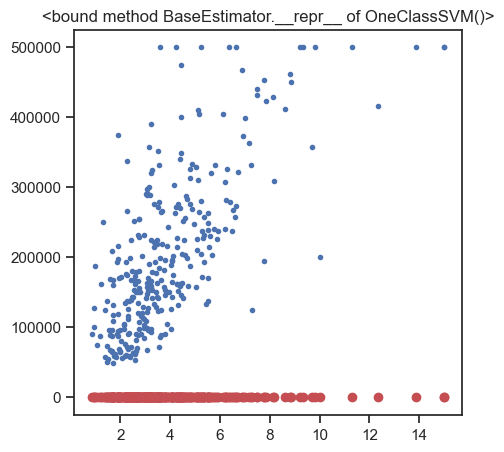

In [ ]:
plot_regr(OneClassSVM())

## Дополнительные источники

### Рекомендуемые

- Видеолекции [1](https://www.youtube.com/watch?v=Adi67_94_gc) и [2](https://www.youtube.com/watch?v=51k2xilkAbs) профессора К.В. Воронцова на youtube
- [Текст лекции профессора К.В. Воронцова](http://www.ccas.ru/voron/download/SVM.pdf)
- [Презентация к лекции](http://www.machinelearning.ru/wiki/images/a/a0/Voron-ML-Lin-SVM.pdf) профессора К.В. Воронцова
- [Описание метода на machinelearning.ru](http://www.machinelearning.ru/wiki/index.php?title=SVM)
- [Глава из книги Дж. Вандер Пласа "Python для сложных задач. Наука о данных и машинное обучение"](https://jakevdp.github.io/PythonDataScienceHandbook/05.07-support-vector-machines.html)
- [SVM. Объяснение с нуля и реализация на python](https://habr.com/ru/company/ods/blog/484148/)
- [Курс лекций](http://www.uic.unn.ru/~zny/ml/) Н.Ю.Золотых по машинному обучению. В [презентации](http://www.uic.unn.ru/~zny/ml/Course/12.Support%20Vector%20Machine.pdf)  рассматривается метод SVM.
- [Support Vector Machine introduction](https://pythonprogramming.net/support-vector-machine-intro-machine-learning-tutorial/)

### Вспомогательные

- https://www.quantstart.com/articles/Support-Vector-Machines-A-Guide-for-Beginners
- https://towardsdatascience.com/support-vector-machine-introduction-to-machine-learning-algorithms-934a444fca47
- https://www.datacamp.com/community/tutorials/svm-classification-scikit-learn-python
- https://pythonspot.com/support-vector-machine/